## Section 1 — Setup and Data Loading

Daily Challenge: Pokemon Win Prediction Analysis (15 XP)

Two datasets, loaded directly from GitHub:
- `pokemon.csv` — stats (HP, Attack, Defense, Speed, etc.) for 800+ Pokemon
- `combats.csv` — 50,000 individual battle records (First_pokemon,
  Second_pokemon, Winner — all by Pokemon ID)

Goal: merge these into a per-Pokemon win percentage, then build regression
models to predict that win percentage from stats.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pokemon_url = "https://raw.githubusercontent.com/bjpark0805/Pokemon_project/master/data/pokemon.csv"
combats_url = "https://raw.githubusercontent.com/bjpark0805/Pokemon_project/master/data/combats.csv"

pokemon = pd.read_csv(pokemon_url)
combats = pd.read_csv(combats_url)

print(f"Pokemon shape: {pokemon.shape}")
print(f"Combats shape: {combats.shape}")
pokemon.head()

Pokemon shape: (800, 12)
Combats shape: (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [2]:
print("Row for Pokemon #62:")
print(pokemon[pokemon['#'] == 62])

print(f"\nMissing Name values: {pokemon['Name'].isnull().sum()}")
print(f"Missing Type 2 values: {pokemon['Type 2'].isnull().sum()}")

Row for Pokemon #62:
     #    Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
61  62  Mankey  Fighting    NaN  40      80       35       35       45     70   

    Generation  Legendary  
61           1      False  

Missing Name values: 1
Missing Type 2 values: 386


In [3]:
print("Row with missing Name:")
print(pokemon[pokemon['Name'].isnull()])

print("\nRow for Pokemon #63:")
print(pokemon[pokemon['#'] == 63])

Row with missing Name:
     # Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
62  63  NaN  Fighting    NaN  65     105       60       60       70     95   

    Generation  Legendary  
62           1      False  

Row for Pokemon #63:
     # Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
62  63  NaN  Fighting    NaN  65     105       60       60       70     95   

    Generation  Legendary  
62           1      False  


In [4]:
pokemon.loc[pokemon['#'] == 63, 'Name'] = 'Primeape'

pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

print(f"Missing Name values: {pokemon['Name'].isnull().sum()}")
print(f"Missing Type 2 values: {pokemon['Type 2'].isnull().sum()}")
print("\nVerifying fix for Pokemon #63:")
print(pokemon[pokemon['#'] == 63])

Missing Name values: 0
Missing Type 2 values: 0

Verifying fix for Pokemon #63:
     #      Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
62  63  Primeape  Fighting   None  65     105       60       60       70   

    Speed  Generation  Legendary  
62     95           1      False  


In [5]:
total_fights = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts()

total_wins = combats['Winner'].value_counts()

win_pct = (total_wins / total_fights * 100).fillna(0)

print(f"Number of Pokemon with fight data: {len(total_fights)}")
print(f"Pokemon with zero fights: {total_fights.isnull().sum()}")
print("\nWin percentage - first 10:")
print(win_pct.head(10))

Number of Pokemon with fight data: 784
Pokemon with zero fights: 0

Win percentage - first 10:
Winner
1     27.819549
2     38.016529
3     67.424242
4     56.000000
5     49.107143
6     54.237288
7     86.466165
8     85.611511
9     84.444444
10    16.239316
Name: count, dtype: float64


In [6]:
pokemon['Win_Percentage'] = pokemon['#'].map(win_pct)

print(f"Pokemon with missing Win_Percentage: {pokemon['Win_Percentage'].isnull().sum()}")

pokemon_clean = pokemon.dropna(subset=['Win_Percentage']).copy()

print(f"Shape after dropping Pokemon with no fight data: {pokemon_clean.shape}")
pokemon_clean.head()

Pokemon with missing Win_Percentage: 16
Shape after dropping Pokemon with no fight data: (784, 13)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,49.107143


### Data Preparation — Results & Interpretation

**Fixes applied:**
- Row index 62 (Pokemon ID #63) had a missing `Name` — identified as
  Primeape (Mankey's evolution, matching stats and sequential ID) and
  corrected. Note: the brief's "#62" referred to the row's position in the
  dataframe, not the Pokemon ID column — these differ by one since indexing
  starts at 0.
- 386 missing `Type 2` values filled with the string "None" (many Pokemon
  are genuinely single-typed, so this is expected, not a data error)

**Win percentage calculation:**
- Computed from 50,000 individual battle records: wins ÷ total fights × 100
  per Pokemon
- 784 of 800 Pokemon had combat history; 16 never appeared in any battle
  and were

## Section 2 — Exploratory Analysis & Visualization

Goal: understand which Pokemon stats relate most strongly to win
percentage, before building predictive models.

Steps:
1. Correlation matrix — HP, Attack, Defense, Sp. Atk, Sp. Def, Speed vs.
   Win_Percentage
2. Pairplot/PairGrid — visualize stats vs. win percentage relationships
3. Top 10 Pokemon by win percentage — examine what makes them successful

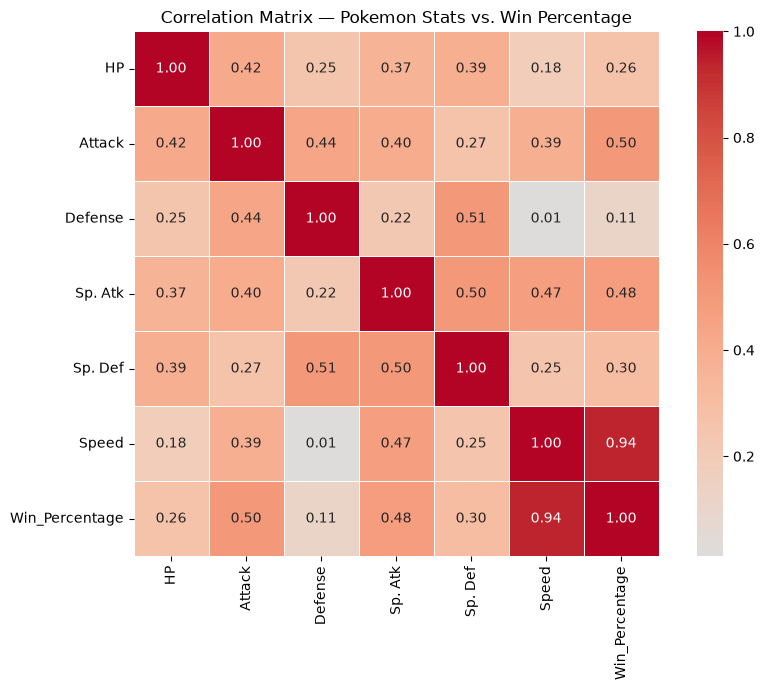

Correlations with Win_Percentage (sorted):
Win_Percentage    1.000000
Speed             0.938055
Attack            0.502825
Sp. Atk           0.481445
Sp. Def           0.302422
HP                0.261602
Defense           0.114565
Name: Win_Percentage, dtype: float64


In [7]:
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']

correlation_matrix = pokemon_clean[stats_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix — Pokemon Stats vs. Win Percentage')
plt.tight_layout()
plt.show()

print("Correlations with Win_Percentage (sorted):")
print(correlation_matrix['Win_Percentage'].sort_values(ascending=False))

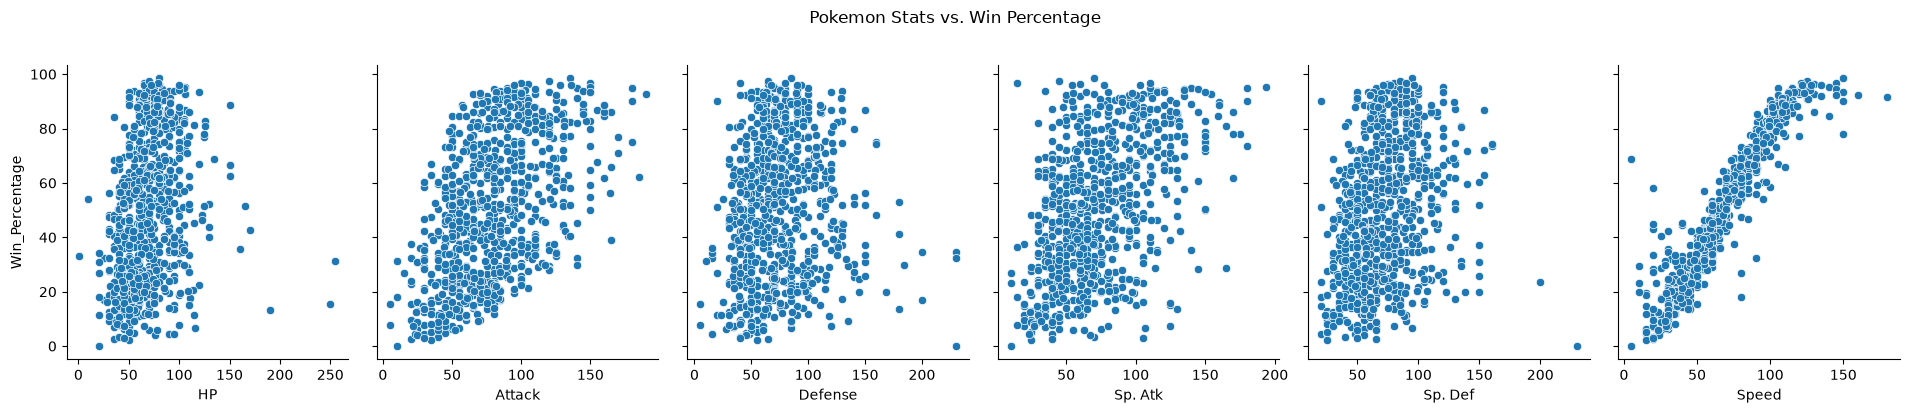

In [8]:
pairplot_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']

sns.pairplot(pokemon_clean[pairplot_cols], y_vars=['Win_Percentage'], x_vars=['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'], height=4, aspect=0.8)
plt.suptitle('Pokemon Stats vs. Win Percentage', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
top_10 = pokemon_clean.nlargest(10, 'Win_Percentage')[['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']]

print("Top 10 Pokemon by Win Percentage:")
print(top_10.to_string(index=False))

print(f"\nAverage Speed of top 10: {top_10['Speed'].mean():.2f}")
print(f"Average Speed of all Pokemon: {pokemon_clean['Speed'].mean():.2f}")

Top 10 Pokemon by Win Percentage:
                    Name  Type 1   Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Win_Percentage
         Mega Aerodactyl    Rock   Flying  80     135       85       70       95    150       98.449612
                 Weavile    Dark      Ice  70     120       65       45       85    125       97.478992
  Tornadus Therian Forme  Flying     None  79     100       80      110       90    121       96.800000
           Mega Beedrill     Bug   Poison  65     150       40       15       80    145       96.638655
              Aerodactyl    Rock   Flying  80     105       65       60       75    130       96.453901
            Mega Lopunny  Normal Fighting  65     136       94       54       96    135       96.124031
                Greninja   Water     Dark  72      95       67      103       71    122       96.062992
Meloetta Pirouette Forme  Normal Fighting 100     128       90       77       77    128       95.934959
           Mega Mewtwo Y Psych

### Section 2 — Results & Interpretation

**Correlation with Win_Percentage (strongest to weakest):**
- Speed: 0.938 — dramatically stronger than any other stat
- Attack: 0.503
- Sp. Atk: 0.481
- Sp. Def: 0.302
- HP: 0.262
- Defense: 0.115

**Pairplot:** visually confirmed the correlation numbers — Speed shows a
tight, near-linear relationship with Win_Percentage, while other stats show
much noisier, weaker trends.

**Top 10 Pokemon by win percentage:** average Speed of 130.10, nearly double
the dataset average of 68.36. 6 of the top 10 are "Mega" evolved forms
(temporary powered-up states with boosted stats across the board).

**Interpretation:** Speed is overwhelmingly the dominant predictor of battle
success in this dataset — far more influential than raw offensive or
defensive stats. This makes mechanical sense: in a simplified 1-on-1 combat
simulation, the faster Pokemon typically acts first each turn, which can be
decisive, especially against lower-HP opponents. This is a genuine, strong
finding, but it's also a somewhat "obvious" one once understood mechanically
— similar to how RAM alone predicted phone price tier almost perfectly in
an earlier exercise. It sets a clear expectation for Section 3: any
reasonable regression model should perform well here, since one feature
alone (Speed) already explains ~88% of the variance (0.938² ≈ 0.88).


## Section 3 — Machine Learning

Goal: predict Win_Percentage from Pokemon stats using regression, and
compare 3 models: Linear Regression, Random Forest, and XGBoost.

Steps:
1. Prepare features (numeric stats only) and target (Win_Percentage)
2. 80/20 train/test split
3. Train and evaluate all 3 models using Mean Absolute Error (MAE)
4. Compare performance

In [10]:
feature_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = pokemon_clean[feature_cols]
y = pokemon_clean['Win_Percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (627, 6)
Test set shape: (157, 6)


In [11]:
!pip install xgboost --quiet
from xgboost import XGBRegressor

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

# XGBoost
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"Linear Regression MAE: {lr_mae:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Linear Regression MAE: 6.1531
Random Forest MAE: 4.4712
XGBoost MAE: 4.5546


In [12]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae]
})
comparison_df = comparison_df.sort_values('MAE').reset_index(drop=True)

print(comparison_df)

best_mae = comparison_df['MAE'].min()
worst_mae = comparison_df['MAE'].max()
improvement = ((worst_mae - best_mae) / worst_mae) * 100
print(f"\nBest model: {comparison_df.iloc[0]['Model']} (MAE: {best_mae:.4f})")
print(f"Improvement over weakest model: {improvement:.2f}%")

               Model       MAE
0      Random Forest  4.471157
1            XGBoost  4.554639
2  Linear Regression  6.153125

Best model: Random Forest (MAE: 4.4712)
Improvement over weakest model: 27.34%


### Section 3 — Results & Interpretation

**Model comparison (Mean Absolute Error, lower is better):**
| Model              | MAE     |
|--------------------|---------|
| Random Forest       | 4.4712  |
| XGBoost             | 4.5546  |
| Linear Regression   | 6.1531  |

**Winner: Random Forest**, with a 27.34% improvement in prediction error
over the weakest model (Linear Regression). XGBoost performs nearly as well,
essentially tied with Random Forest (difference of only ~0.08 MAE).

**Interpretation:** both tree-based models (Random Forest, XGBoost)
meaningfully outperform plain Linear Regression. This lines up with
Section 2's EDA — while Speed shows a strong linear relationship with
Win_Percentage, other stats (Attack, Sp. Atk) show noisier, more complex
patterns that tree-based models can capture better than a single straight
line. On average, Random Forest's predictions land within about 4.47
percentage points of a Pokemon's true win rate — a solid result, especially
given Speed alone already explains ~88% of the variance (r² ≈ 0.88), leaving
tree-based models to squeeze out real, if smaller, gains from the
remaining, noisier stats.

## Section 4 — Bonus: Dimensionality Reduction with PCA

The learning objectives list PCA as a technique to explore, even though it
wasn't part of the required numbered tasks. This is a quick demonstration
of how PCA works on our 6 numeric stats, showing how much of the original
information can be preserved in fewer dimensions.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pokemon_clean[feature_cols])

pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)

print(f"\nCumulative variance explained by first 2 components: {pca.explained_variance_ratio_[:2].sum():.4f}")
print(f"Cumulative variance explained by first 3 components: {pca.explained_variance_ratio_[:3].sum():.4f}")

Explained variance ratio per component:
[0.45300762 0.1831929  0.12811758 0.1194177  0.07152221 0.04474199]

Cumulative variance explained by first 2 components: 0.6362
Cumulative variance explained by first 3 components: 0.7643


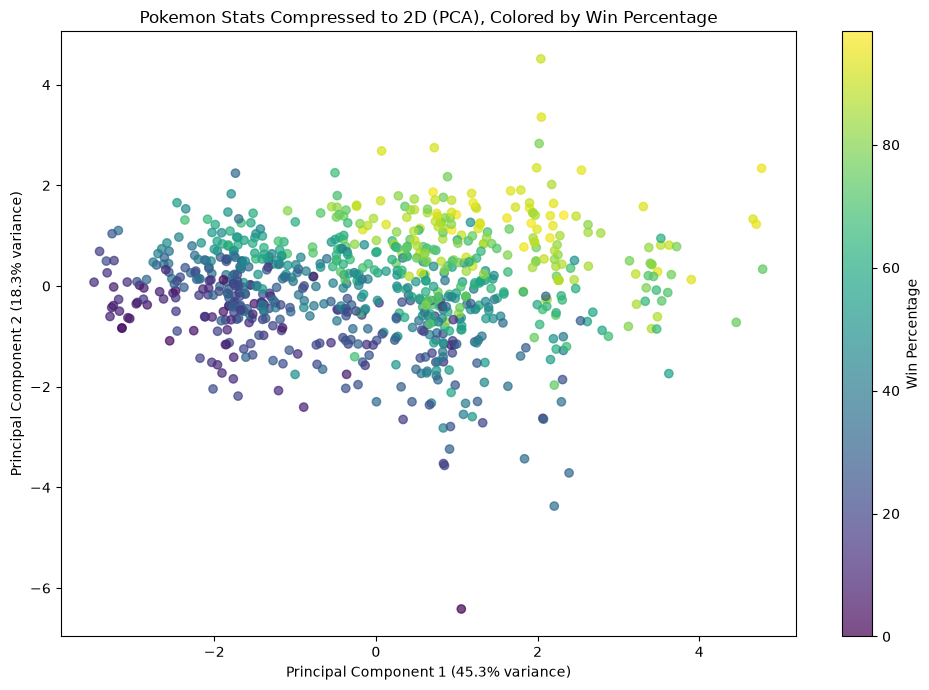

In [14]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pokemon_clean['Win_Percentage'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Win Percentage')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Pokemon Stats Compressed to 2D (PCA), Colored by Win Percentage')
plt.tight_layout()
plt.show()

### Section 4 — Results & Interpretation

**PCA variance explained:** Component 1 alone captures 45.3% of the total
variance across the 6 stats; the first 2 components together capture 63.6%.

**2D visualization:** plotting all 784 Pokemon using only the first 2
components, colored by actual Win_Percentage, reveals a visible left-to-right
gradient — low win-rate Pokemon (dark purple) cluster toward the left,
high win-rate Pokemon (yellow/green) cluster toward the right, primarily
along Principal Component 1.

**Interpretation:** even compressed into just 2 dimensions, the data
retains enough structure to visually separate high- and low-performing
Pokemon. This is consistent with Section 2 and 3's findings — since Speed
so strongly predicts Win_Percentage, and Speed contributes to PC1, the
dominant component likely reflects much of that same Speed-driven pattern.
This demonstrates PCA's core value: reducing many correlated features down
to a small number of components while retaining most of the meaningful
signal — useful for visualization and potentially for simplifying models
when working with far more features than the 6 we have here.